<table width="100%">
  <tr>
    <td align="left" valign="middle" width="100%">
      <img src="../docs/assets/logo_bristol.png" alt="University of Bristol" width="200" />
    </td>
    <td align="right" valign="middle" width="100%">
      <img src="../docs/assets/logo_ufpe.png" alt="UFPE" width="130" />
      &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;
      <img src="../docs/assets/logo_kunumi.png" alt="Kunumi" width="150" />
      &nbsp;&nbsp;
    </td>
  </tr>
</table>

---

In [1]:
from nb_utils import set_root

PROJECT_ROOT = set_root(level=2)


# Answer 1: Unsupervised Evaluation Beyond Aggregate Metrics

This notebook provides one worked solution path for the Section 1 activity.


## Activity Goals

By the end of this notebook, you should be able to:

- generate or adapt a toy clustering scenario;
- compare clustering models using aggregate metrics;
- inspect instance-level difficulty through model agreement;
- discuss why aggregate clustering evaluation can hide important structure.


In [2]:
import matplotlib.pyplot as plt

from utils.handson import (
    evaluate_clustering_models_on_dataset,
    make_toy_clustering_dataset,
    plot_clustering_dataset,
    plot_clustering_instance_difficulty,
    summarize_clustering_instance_difficulty,
    summarize_clustering_results,
)


## Starter Scenario

Start from one of the toy clustering scenarios used in the guided notebook.


## Task 1

Create a **new toy clustering dataset**.

Suggested options:

- `scenario='easy_blobs'`
- `scenario='hard_moons'`
- `scenario='hard_circles'`

You can also change:

- `n_samples`
- `random_state`


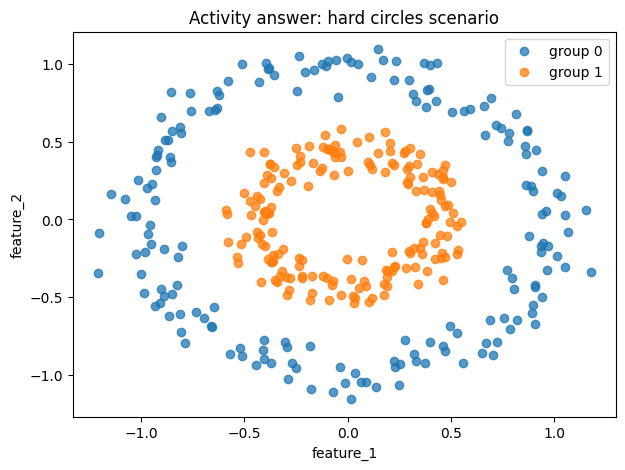

,feature_1,feature_2,label,instance_id,scenario_name
0,-0.671356,0.696224,0,0,hard_circles
1,0.529540,-0.732262,0,1,hard_circles
2,-0.888868,-0.193099,0,2,hard_circles
3,0.055536,-0.440639,1,3,hard_circles
4,-0.981768,-0.210887,0,4,hard_circles


In [3]:
scenario = 'hard_circles'
random_state = 21

df = make_toy_clustering_dataset(
    scenario=scenario,
    n_samples=360,
    random_state=random_state,
)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plot_clustering_dataset(df, ax=ax, title='Activity answer: hard circles scenario')
plt.show()

df.head()


## Task 2

Evaluate the clustering models on your scenario and compare the metrics.

Focus on whether the models agree on the ranking and whether the scenario seems easy or hard.


In [4]:
assignments = evaluate_clustering_models_on_dataset(
    df,
    scenario=scenario,
    random_state=random_state,
)

results = summarize_clustering_results(assignments)
results


,scenario,model,ari,n_predicted_clusters,silhouette,calinski_harabasz,davies_bouldin
0,hard_circles,spectral,1.000000,2,0.127004,0.044465,83.675757
1,hard_circles,agglomerative,0.001014,2,0.319275,177.067041,1.246119
2,hard_circles,kmeans,-0.002664,2,0.343885,200.486151,1.187927


## Task 3

Inspect the difficult instances using the agreement-based proxy and discuss the result.


100%|██████████| 3/3 [00:00<00:00, 317.29it/s]


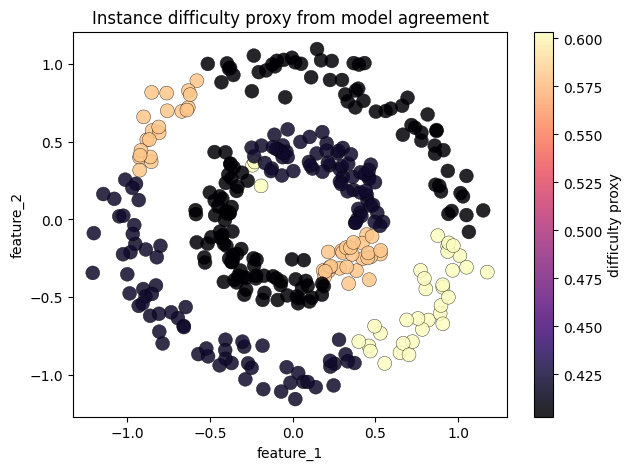

,instance_id,feature_1,feature_2,label,scenario,mean_model_agreement,difficulty_proxy
0,1,0.529540,-0.732262,0,hard_circles,0.396472,0.603528
1,10,0.555851,-0.926257,0,hard_circles,0.396472,0.603528
2,19,1.010284,-0.233343,0,hard_circles,0.396472,0.603528
3,23,0.772913,-0.327592,0,hard_circles,0.396472,0.603528
4,43,0.494666,-0.686907,0,hard_circles,0.396472,0.603528
5,44,1.050972,-0.307448,0,hard_circles,0.396472,0.603528
6,57,1.176356,-0.338637,0,hard_circles,0.396472,0.603528
7,85,0.936670,-0.171674,0,hard_circles,0.396472,0.603528
8,88,0.907101,-0.436629,0,hard_circles,0.396472,0.603528
9,104,0.906781,-0.420669,0,hard_circles,0.396472,0.603528


In [5]:
instance_summary = summarize_clustering_instance_difficulty(assignments)

fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plot_clustering_instance_difficulty(instance_summary, ax=ax)
plt.show()

instance_summary.head(12)


## Reflection Questions

1. Which metric seems most stable across scenarios?
2. Which model appears most sensitive to difficult geometric structure?
3. Do the difficult instances appear in obvious boundary or ambiguous regions?
4. Why does this motivate a latent-variable view of evaluation?
